In [1]:
import pandas as pd

file_path = '/content/insumos_cancer_final.csv'
df = pd.read_csv(file_path)

display(df.head())

,fecha,dia_semana,semana,mes,anio,ocupacion_deseada,ocupacion_albergue,capacidad_albergue,porcentaje_ocupacion,pacientes_total,...,stock_proyectado_14d,stock_critico_7d,stock_critico_14d,stock_critico,ratio_stock_minimo,dias_cobertura,neto_movimiento,variabilidad_consumo,es_ocupacion_alta,ratio_pacientes_alta_prioridad
0,2025-03-14,viernes,11,3,2025,51,51,100,0.51,51,...,150.0,no,no,no,3.661972,11.304348,-22,0.000000,0,0.365385
1,2025-03-15,sabado,11,3,2025,50,50,100,0.50,50,...,123.0,no,no,no,3.352113,12.526316,-18,0.173913,0,0.313725
2,2025-03-16,domingo,11,3,2025,52,52,100,0.52,52,...,108.0,no,no,no,3.098592,9.565217,-22,0.095238,0,0.339623
3,2025-03-17,lunes,12,3,2025,56,56,100,0.56,56,...,87.0,no,no,no,2.788732,22.000000,-8,0.584679,0,0.315789
4,2025-03-18,martes,12,3,2025,56,56,100,0.56,56,...,78.0,no,no,no,2.676056,63.333333,-2,0.837838,0,0.333333


## Análisis Exploratorio de Datos (EDA)

In [2]:
# 1. Información general del DataFrame: tipos de datos y valores no nulos
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5010 entries, 0 to 5009
Data columns (total 57 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   fecha                             5010 non-null   object 
 1   dia_semana                        5010 non-null   object 
 2   semana                            5010 non-null   int64  
 3   mes                               5010 non-null   int64  
 4   anio                              5010 non-null   int64  
 5   ocupacion_deseada                 5010 non-null   int64  
 6   ocupacion_albergue                5010 non-null   int64  
 7   capacidad_albergue                5010 non-null   int64  
 8   porcentaje_ocupacion              5010 non-null   float64
 9   pacientes_total                   5010 non-null   int64  
 10  pacientes_prioridad_baja          5010 non-null   int64  
 11  pacientes_prioridad_media         5010 non-null   int64  
 12  pacien

None

In [3]:
# 2. Estadísticas descriptivas para columnas numéricas
display(df.describe())

,semana,mes,anio,ocupacion_deseada,ocupacion_albergue,capacidad_albergue,porcentaje_ocupacion,pacientes_total,pacientes_prioridad_baja,pacientes_prioridad_media,...,demanda_7_dias,demanda_14_dias,stock_proyectado_7d,stock_proyectado_14d,ratio_stock_minimo,dias_cobertura,neto_movimiento,variabilidad_consumo,es_ocupacion_alta,ratio_pacientes_alta_prioridad
count,5010.000000,5010.000000,5010.0,5010.000000,5010.000000,5010.0,5010.000000,5010.000000,5010.000000,5010.000000,...,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000
mean,28.077844,6.907186,2025.0,74.155689,74.155689,100.0,0.741557,74.155689,20.988024,26.880240,...,118.738822,239.204167,170.713772,101.516542,2.753219,42.447678,-16.863074,0.486524,0.491018,0.348483
std,14.668627,3.355607,0.0,14.268331,14.268331,0.0,0.142683,14.268331,5.832035,5.901266,...,114.279938,227.634360,143.364029,115.701575,0.896129,69.874580,17.404963,0.647047,0.499969,0.053150
min,1.000000,1.000000,2025.0,50.000000,50.000000,100.0,0.500000,50.000000,8.000000,12.000000,...,0.000000,3.000000,0.000000,0.000000,1.230769,1.936170,-68.000000,0.000000,0.000000,0.215686
25%,17.000000,4.000000,2025.0,62.000000,62.000000,100.0,0.620000,62.000000,17.000000,23.000000,...,21.000000,43.000000,66.000000,0.000000,2.065462,11.806784,-29.000000,0.118161,0.000000,0.313725
50%,29.000000,7.000000,2025.0,74.000000,74.000000,100.0,0.740000,74.000000,20.000000,27.000000,...,84.000000,172.000000,128.000000,67.000000,2.679402,21.651515,-9.000000,0.300699,0.000000,0.349022
75%,41.000000,10.000000,2025.0,86.000000,86.000000,100.0,0.860000,86.000000,25.000000,31.000000,...,182.750000,371.750000,224.000000,137.750000,3.318182,44.805556,-3.000000,0.610895,1.000000,0.383721
max,52.000000,12.000000,2025.0,100.000000,100.000000,100.0,1.000000,100.000000,37.000000,40.000000,...,425.375000,864.875000,461.000000,369.875000,5.660714,806.500000,0.000000,6.512953,1.000000,0.537313


In [4]:
# 3. Conteo de valores faltantes por columna
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

,0


### Preparación de Datos: Conversión de la columna 'fecha' a tipo datetime

In [5]:
df['fecha'] = pd.to_datetime(df['fecha'])
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5010 entries, 0 to 5009
Data columns (total 57 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   fecha                             5010 non-null   datetime64[ns]
 1   dia_semana                        5010 non-null   object        
 2   semana                            5010 non-null   int64         
 3   mes                               5010 non-null   int64         
 4   anio                              5010 non-null   int64         
 5   ocupacion_deseada                 5010 non-null   int64         
 6   ocupacion_albergue                5010 non-null   int64         
 7   capacidad_albergue                5010 non-null   int64         
 8   porcentaje_ocupacion              5010 non-null   float64       
 9   pacientes_total                   5010 non-null   int64         
 10  pacientes_prioridad_baja          5010 non-null 

None

### 4. Distribución de Variables Numéricas Clave

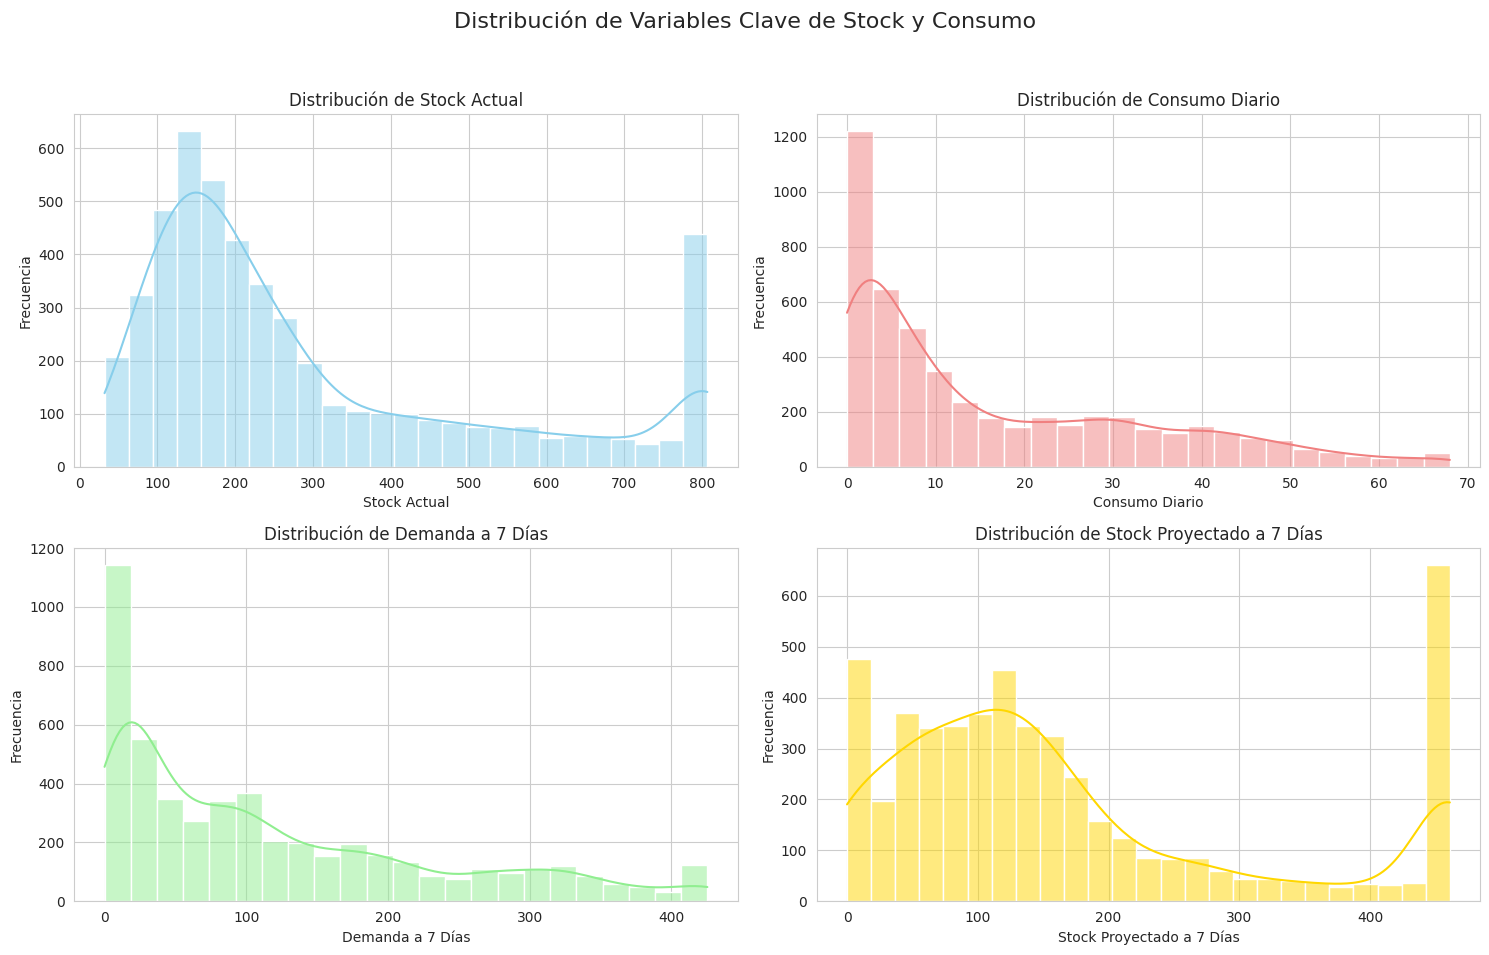

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de los gráficos
sns.set_style('whitegrid')

# Crear histogramas para las variables clave de stock y consumo
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribución de Variables Clave de Stock y Consumo', fontsize=16)

sns.histplot(df['stock_actual'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribución de Stock Actual')
axes[0, 0].set_xlabel('Stock Actual')
axes[0, 0].set_ylabel('Frecuencia')

sns.histplot(df['consumo_diario'], kde=True, ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Distribución de Consumo Diario')
axes[0, 1].set_xlabel('Consumo Diario')
axes[0, 1].set_ylabel('Frecuencia')

sns.histplot(df['demanda_7_dias'], kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Distribución de Demanda a 7 Días')
axes[1, 0].set_xlabel('Demanda a 7 Días')
axes[1, 0].set_ylabel('Frecuencia')

sns.histplot(df['stock_proyectado_7d'], kde=True, ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Distribución de Stock Proyectado a 7 Días')
axes[1, 1].set_xlabel('Stock Proyectado a 7 Días')
axes[1, 1].set_ylabel('Frecuencia')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 5. Análisis de Variables Categóricas

In [7]:
# Contar valores únicos para algunas columnas categóricas clave
print("Valores únicos en 'dia_semana':\n", df['dia_semana'].value_counts())
print("\nValores únicos en 'categoria_item':\n", df['categoria_item'].value_counts())
print("\nValores únicos en 'tipo_stock':\n", df['tipo_stock'].value_counts())
print("\nConteo de 'stock_critico':\n", df['stock_critico'].value_counts())
print("\nConteo de 'stock_critico_7d':\n", df['stock_critico_7d'].value_counts())
print("\nConteo de 'stock_critico_14d':\n", df['stock_critico_14d'].value_counts())

Valores únicos en 'dia_semana':
 dia_semana
viernes      720
sabado       720
domingo      720
lunes        720
martes       720
miercoles    705
jueves       705
Name: count, dtype: int64

Valores únicos en 'categoria_item':
 categoria_item
fluoropirimidina_iv       334
fluoropirimidina_oral     334
platino_oxaliplatino      334
platino_cisplatino        334
leucovorina               334
taxano_docetaxel          334
taxano_paclitaxel         334
platino_carboplatino      334
anti_her2                 334
antiemetico               334
corticoide_antiemetico    334
protector_gastrico        334
opioide                   334
nutricional               334
curacion                  334
Name: count, dtype: int64

Valores únicos en 'tipo_stock':
 tipo_stock
antineoplasico         2672
soporte                1002
terapia_dirigida        334
soporte_paliativo       334
soporte_nutricional     334
insumo_clinico          334
Name: count, dtype: int64

Conteo de 'stock_critico':
 stock_critico


### 6. Análisis de Series de Tiempo: Tendencias de Stock y Consumo

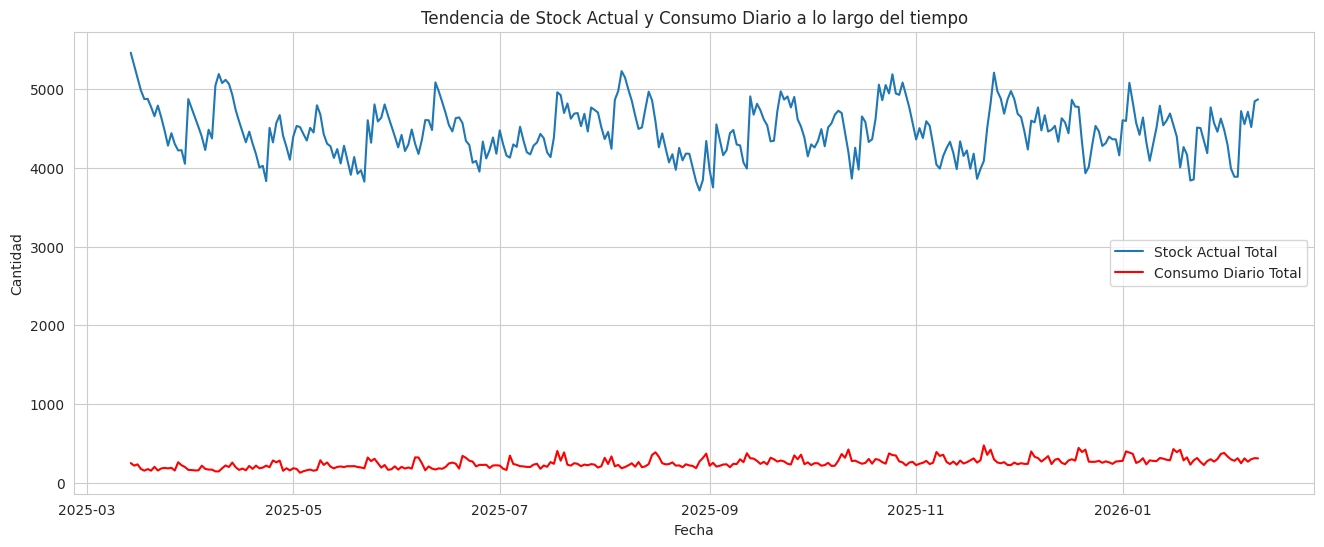

In [8]:
# Agrupar por fecha para visualizar las tendencias generales
daily_trends = df.groupby('fecha')[['stock_actual', 'consumo_diario']].sum().reset_index()

plt.figure(figsize=(16, 6))
sns.lineplot(x='fecha', y='stock_actual', data=daily_trends, label='Stock Actual Total')
sns.lineplot(x='fecha', y='consumo_diario', data=daily_trends, label='Consumo Diario Total', color='red')
plt.title('Tendencia de Stock Actual y Consumo Diario a lo largo del tiempo')
plt.xlabel('Fecha')
plt.ylabel('Cantidad')
plt.legend()
plt.grid(True)
plt.show()

### 7. Análisis de Estacionalidad

/tmp/ipykernel_16934/1208651300.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekly_consumption.index, y=weekly_consumption.values, palette='viridis')


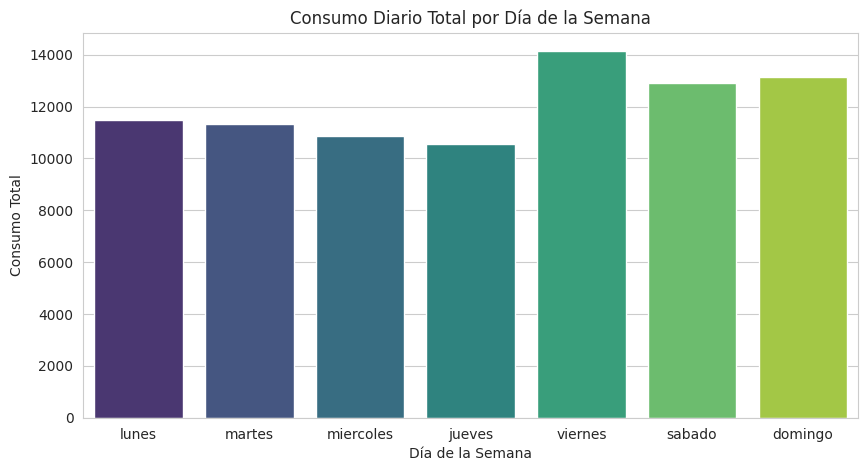

/tmp/ipykernel_16934/1208651300.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_consumption.index, y=monthly_consumption.values, palette='magma')


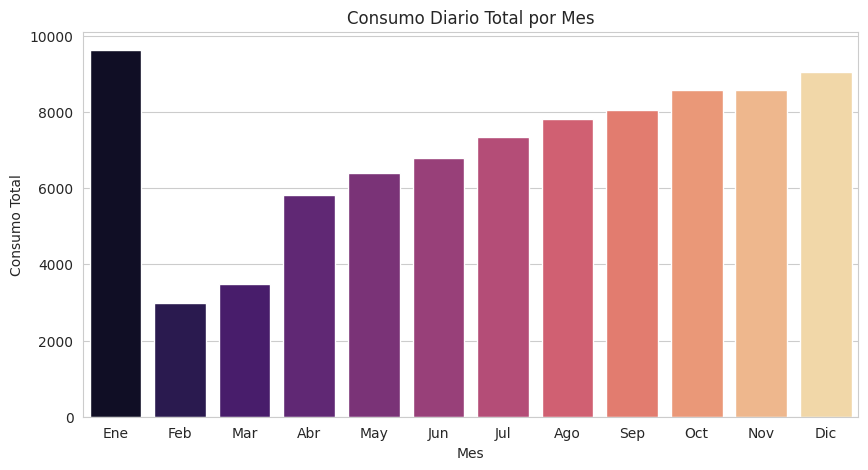

In [9]:
# Analizar estacionalidad por día de la semana para consumo
weekly_consumption = df.groupby('dia_semana')['consumo_diario'].sum().reindex(['lunes', 'martes', 'miercoles', 'jueves', 'viernes', 'sabado', 'domingo'])

plt.figure(figsize=(10, 5))
sns.barplot(x=weekly_consumption.index, y=weekly_consumption.values, palette='viridis')
plt.title('Consumo Diario Total por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Consumo Total')
plt.show()

# Analizar estacionalidad por mes para consumo
monthly_consumption = df.groupby('mes')['consumo_diario'].sum()

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_consumption.index, y=monthly_consumption.values, palette='magma')
plt.title('Consumo Diario Total por Mes')
plt.xlabel('Mes')
plt.ylabel('Consumo Total')
plt.xticks(ticks=range(12), labels=['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.show()

### 8. Correlación entre Variables Numéricas

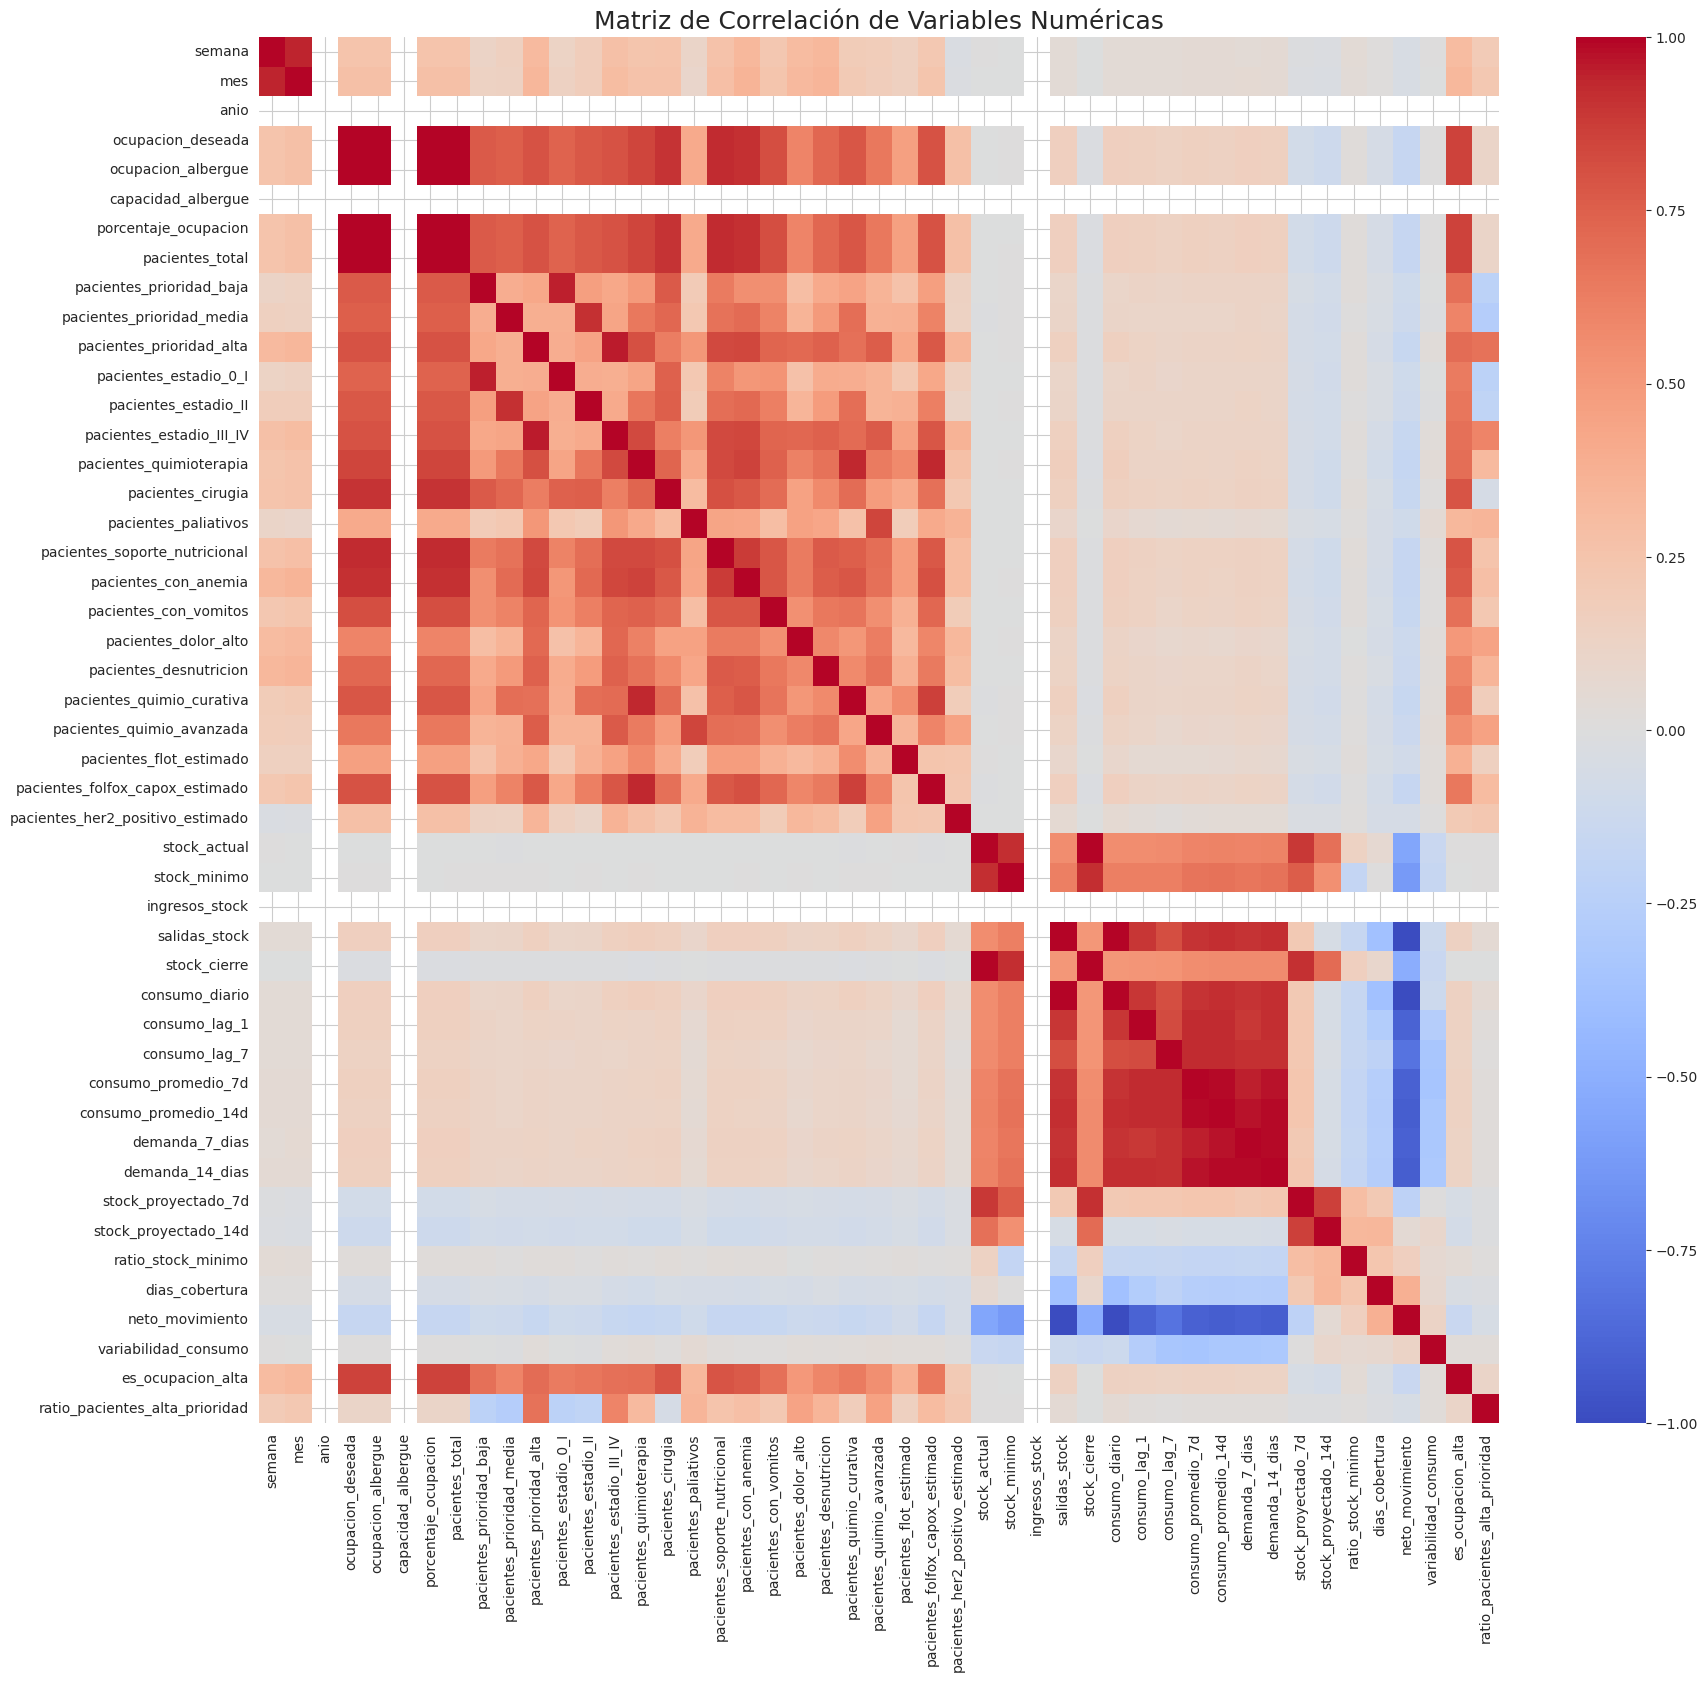

In [10]:
import numpy as np

# Seleccionar solo columnas numéricas para la matriz de correlación
numerical_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numerical_cols].corr()

# Visualizar la matriz de correlación (heatmap)
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=18)
plt.show()

## Hito 2: Preparación de Datos (Fase 3 de CRISP-DM)

### Creación de Nuevas Variables (Feature Engineering)

In [11]:
# 1. Crear la variable 'is_weekend'
df['dia_semana_num'] = df['fecha'].dt.dayofweek # Lunes=0, Domingo=6
df['is_weekend'] = df['dia_semana_num'].apply(lambda x: 1 if x >= 5 else 0)

# 2. Proyección de Crecimiento: Escalado de variables relacionadas con pacientes y ocupación
# Asumimos que un crecimiento de 50 a 100 familias implica duplicar las métricas de pacientes y ocupación.
# Identificamos las columnas a escalar:
paciente_ocupacion_cols = [
    'ocupacion_deseada', 'ocupacion_albergue', 'porcentaje_ocupacion',
    'pacientes_total', 'pacientes_prioridad_baja', 'pacientes_prioridad_media',
    'pacientes_prioridad_alta', 'pacientes_estadio_0_I', 'pacientes_estadio_II',
    'pacientes_estadio_III_IV', 'pacientes_quimioterapia', 'pacientes_cirugia',
    'pacientes_paliativos', 'pacientes_soporte_nutricional', 'pacientes_con_anemia',
    'pacientes_con_vomitos', 'pacientes_dolor_alto', 'pacientes_desnutricion',
    'pacientes_quimio_curativa', 'pacientes_quimio_avanzada',
    'pacientes_flot_estimado', 'pacientes_folfox_capox_estimado',
    'pacientes_her2_positivo_estimado'
]

# Creamos nuevas columnas con el sufijo '_scaled_100_familias'
for col in paciente_ocupacion_cols:
    df[f'{col}_scaled_100_familias'] = df[col] * 2  # Duplicamos los valores

# Mostramos las primeras filas con las nuevas características
display(df.head())

,fecha,dia_semana,semana,mes,anio,ocupacion_deseada,ocupacion_albergue,capacidad_albergue,porcentaje_ocupacion,pacientes_total,...,pacientes_soporte_nutricional_scaled_100_familias,pacientes_con_anemia_scaled_100_familias,pacientes_con_vomitos_scaled_100_familias,pacientes_dolor_alto_scaled_100_familias,pacientes_desnutricion_scaled_100_familias,pacientes_quimio_curativa_scaled_100_familias,pacientes_quimio_avanzada_scaled_100_familias,pacientes_flot_estimado_scaled_100_familias,pacientes_folfox_capox_estimado_scaled_100_familias,pacientes_her2_positivo_estimado_scaled_100_familias
0,2025-03-14,viernes,11,3,2025,51,51,100,0.51,51,...,88,70,44,28.0,24.0,46,12,18,36,2.0
1,2025-03-15,sabado,11,3,2025,50,50,100,0.50,50,...,80,64,42,26.0,24.0,30,18,10,32,4.0
2,2025-03-16,domingo,11,3,2025,52,52,100,0.52,52,...,80,74,44,26.0,32.0,34,18,16,30,4.0
3,2025-03-17,lunes,12,3,2025,56,56,100,0.56,56,...,80,72,36,34.0,24.0,36,14,8,42,2.0
4,2025-03-18,martes,12,3,2025,56,56,100,0.56,56,...,78,72,46,30.0,24.0,34,24,12,32,4.0


In [12]:
# Verificamos los nuevos tipos de datos y las columnas agregadas
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5010 entries, 0 to 5009
Data columns (total 82 columns):
 #   Column                                                Non-Null Count  Dtype         
---  ------                                                --------------  -----         
 0   fecha                                                 5010 non-null   datetime64[ns]
 1   dia_semana                                            5010 non-null   object        
 2   semana                                                5010 non-null   int64         
 3   mes                                                   5010 non-null   int64         
 4   anio                                                  5010 non-null   int64         
 5   ocupacion_deseada                                     5010 non-null   int64         
 6   ocupacion_albergue                                    5010 non-null   int64         
 7   capacidad_albergue                                    5010 non-null   int64   

None

### Codificación de Variables Categóricas y Definición de Objetivos

In [13]:
# Columnas categóricas a codificar (excluyendo 'fecha' y las targets)
categorical_cols = [
    'dia_semana', 'item_id', 'item_nombre', 'categoria_item', 'tipo_stock', 'unidad_medida'
]

# Aplicar One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Convertir las variables objetivo 'stock_critico_7d' y 'stock_critico_14d' a numérico (0/1)
df_encoded['stock_critico_7d_binary'] = df_encoded['stock_critico_7d'].apply(lambda x: 1 if x == 'si' else 0)
df_encoded['stock_critico_14d_binary'] = df_encoded['stock_critico_14d'].apply(lambda x: 1 if x == 'si' else 0)

# Opcional: Convertir 'stock_critico' original a binario si fuera necesario como target
df_encoded['stock_critico_binary'] = df_encoded['stock_critico'].apply(lambda x: 1 if x == 'si' else 0)

# Eliminar columnas originales de stock crítico y la columna de 'fecha' y 'dia_semana_num' que ya no son necesarias
# También se eliminan las columnas originales de dia_semana y las scaled para evitar duplicidad.
df_final = df_encoded.drop(columns=[
    'fecha', 'dia_semana_num', 'stock_critico', 'stock_critico_7d', 'stock_critico_14d'
])

# Revisa las primeras filas del DataFrame final y sus tipos de datos
display(df_final.head())
display(df_final.info())

,semana,mes,anio,ocupacion_deseada,ocupacion_albergue,capacidad_albergue,porcentaje_ocupacion,pacientes_total,pacientes_prioridad_baja,pacientes_prioridad_media,...,tipo_stock_soporte_nutricional,tipo_stock_soporte_paliativo,tipo_stock_terapia_dirigida,unidad_medida_kits,unidad_medida_sobres,unidad_medida_tabletas,unidad_medida_viales,stock_critico_7d_binary,stock_critico_14d_binary,stock_critico_binary
0,11,3,2025,51,51,100,0.51,51,12,20,...,False,False,False,False,False,False,True,0,0,0
1,11,3,2025,50,50,100,0.50,50,18,16,...,False,False,False,False,False,False,True,0,0,0
2,11,3,2025,52,52,100,0.52,52,14,20,...,False,False,False,False,False,False,True,0,0,0
3,12,3,2025,56,56,100,0.56,56,20,18,...,False,False,False,False,False,False,True,0,0,0
4,12,3,2025,56,56,100,0.56,56,14,23,...,False,False,False,False,False,False,True,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5010 entries, 0 to 5009
Columns: 131 entries, semana to stock_critico_binary
dtypes: bool(57), float64(22), int64(52)
memory usage: 3.1 MB


None

## Hito 2: Modelo Base (Fase 4 de CRISP-DM - Modelado)

In [55]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore') # Ignorar warnings para una salida más limpia

In [86]:
df_final.columns.tolist()

<function list.count(value, /)>

### 1. Preparación de Datos para Modelado

In [89]:
# 1. Restringimos los datos al 3er bimestre (meses 5 y 6)
df_modelo = df_final[df_final['mes'].isin([5, 6])].copy()

# 2. Definimos qué vamos a predecir (ejemplo: demanda a 7 días)
y_7d = df_modelo['demanda_7_dias']
y_14d = df_modelo['demanda_14_dias']
# 3. Hacemos una lista con todas las columnas redundantes de nombres de items
columnas_nombres_items = [col for col in df_modelo.columns if col.startswith('item_nombre_')]

# 4. Hacemos una lista con todas las columnas escaladas
columnas_escaladas = [col for col in df_modelo.columns if 'scaled_100_familias' in col]

# 5. Agrupamos todo lo que debemos eliminar de X
columnas_a_eliminar = [
    # Leakage y targets
    'demanda_7_dias', 'demanda_14_dias',
    'stock_proyectado_7d', 'stock_proyectado_14d',
    'stock_critico_7d_binary', 'stock_critico_14d_binary', 'stock_critico_binary'
] + columnas_nombres_items + columnas_escaladas

# 6. Creamos la matriz X final
X = df_modelo.drop(columns=columnas_a_eliminar)

print(f"Dimensiones de X para entrenamiento: {X.shape}")

Dimensiones de X para entrenamiento: (915, 87)


### 2. División de Datos (Entrenamiento y Prueba)

In [117]:
# Dividir los datos para la predicción de demanda a 7 días (Sin stratify)
X_train_7d, X_test_7d, y_train_7d, y_test_7d = train_test_split(
    X, y_7d, test_size=0.2, random_state=42
)

# Dividir los datos para la predicción de demanda a 14 días (Sin stratify)
# Asegúrate de haber definido y_14d previamente (ej: y_14d = df_modelo['demanda_14_dias'])
X_train_14d, X_test_14d, y_train_14d, y_test_14d = train_test_split(
    X, y_14d, test_size=0.2, random_state=42
)

print(f"Tamaño del conjunto de entrenamiento (7d): {X_train_7d.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba (7d): {X_test_7d.shape[0]} muestras")
print(f"Tamaño del conjunto de entrenamiento (14d): {X_train_14d.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba (14d): {X_test_14d.shape[0]} muestras")

Tamaño del conjunto de entrenamiento (7d): 732 muestras
Tamaño del conjunto de prueba (7d): 183 muestras
Tamaño del conjunto de entrenamiento (14d): 732 muestras
Tamaño del conjunto de prueba (14d): 183 muestras


### 3. Entrenamiento y Evaluación de Modelos Base para `stock_critico_7d`

In [111]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

models = {
    # 1. Ridge Regression (Lineal Mejorada)
    # alpha=10.0 aplica una penalización más fuerte a las variables que no aportan mucho,
    # limpiando el ruido de tus datos hospitalarios.
    'Ridge Regression': make_pipeline(StandardScaler(), Ridge(alpha=10.0, random_state=42)),

    # 2. Random Forest "Desencadenado"
    # Quitamos la restricción de 50 muestras. max_features='sqrt' obliga a que los árboles
    # sean más diversos entre sí, lo que mejora muchísimo el ensamble final.
    'Random Forest': RandomForestRegressor(
        n_estimators=200,        # 200 árboles dan mucha más estabilidad
        max_depth=15,            # Profundidad límite para no memorizar
        max_features='sqrt',     # Solo mira una fracción de las columnas en cada corte
        random_state=42,
        n_jobs=-1                # Truco: usa todos los núcleos de tu PC para que entrene rapidísimo
    ),

    # 3. Gradient Boosting Clásico
    # Bajamos el learning_rate y subimos los estimadores. Aprenderá más lento, pero con mucha más precisión.
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,           # Entrena cada árbol con el 80% de los datos (evita overfitting)
        max_features='sqrt',     # Usa menos variables por árbol para evitar que una sola domine
        random_state=42
    ),

    # 4. XGBoost: Modo "Bestia"
    # Activamos sus penalizaciones matemáticas (reg_alpha y reg_lambda) que son su mayor
    # ventaja competitiva frente a los otros algoritmos.
    'XGBoost': XGBRegressor(
        n_estimators=300,        # Más iteraciones porque el learning rate es bajo
        learning_rate=0.05,
        max_depth=6,             # Profundidad moderada
        subsample=0.8,           # Usa el 80% de las filas
        colsample_bytree=0.8,    # Usa el 80% de las columnas
        reg_alpha=1.0,           # Regularización L1 (Lasso): vuelve 0 el peso del ruido
        reg_lambda=1.0,          # Regularización L2 (Ridge): controla los valores extremos
        random_state=42,
        n_jobs=-1                # Entrenamiento en paralelo
    )
}

results_7d = {}

print("--- Modelos para stock_critico_7d ---")

for name, model in models.items():
    print(f"\nEntrenando {name}...")

    # 1. Entrenar y predecir
    model.fit(X_train_7d, y_train_7d)
    y_pred = model.predict(X_test_7d)

    # 2. Calcular métricas de regresión
    mae = mean_absolute_error(y_test_7d, y_pred)
    mse = mean_squared_error(y_test_7d, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_7d, y_pred)

    # 3. Guardar e imprimir (DENTRO DEL BUCLE - nota los espacios a la izquierda)
    results_7d[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2-Score': r2}
    print(f"{name} - MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}, R2-Score: {r2:.4f}")

# 4. Crear y mostrar el DataFrame final (FUERA DEL BUCLE - sin espacios a la izquierda)
results_df_7d = pd.DataFrame(results_7d).T
results_df_7d = results_df_7d.sort_values(by='RMSE', ascending=True)
display(results_df_7d)

--- Modelos para stock_critico_7d ---

Entrenando Ridge Regression...
Ridge Regression - MAE: 12.4272, MSE: 282.9268, RMSE: 16.8204, R2-Score: 0.9694

Entrenando Random Forest...
Random Forest - MAE: 10.3910, MSE: 244.8342, RMSE: 15.6472, R2-Score: 0.9735

Entrenando Gradient Boosting...
Gradient Boosting - MAE: 9.0615, MSE: 172.1073, RMSE: 13.1190, R2-Score: 0.9814

Entrenando XGBoost...
XGBoost - MAE: 7.0503, MSE: 110.0053, RMSE: 10.4883, R2-Score: 0.9881


,MAE,MSE,RMSE,R2-Score
XGBoost,7.050287,110.005326,10.488342,0.988083
Gradient Boosting,9.061520,172.107327,13.118968,0.981356
Random Forest,10.391029,244.834161,15.647177,0.973478
Ridge Regression,12.427213,282.926768,16.820427,0.969351


### 4. Entrenamiento y Evaluación de Modelos Base para `stock_critico_14d`

In [116]:
results_14d = {}

print("--- Modelos para stock_critico_14d ---")
for name, model in models.items(): # Usamos los mismos modelos del diccionario
    print(f"\nEntrenando {name}...")

    # 1. Entrenar y predecir
    model.fit(X_train_14d, y_train_14d)
    y_pred = model.predict(X_test_14d)

    # 2. Calcular métricas de regresión
    mae = mean_absolute_error(y_test_14d, y_pred)
    mse = mean_squared_error(y_test_14d, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_14d, y_pred)

    # 3. Guardar e imprimir los resultados (DENTRO DEL BUCLE)
    results_14d[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2-Score': r2}
    print(f"{name} - MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}, R2-Score: {r2:.4f}")

# 4. Crear, ordenar y mostrar el DataFrame final (FUERA DEL BUCLE)
results_df_14d = pd.DataFrame(results_14d).T
results_df_14d = results_df_14d.sort_values(by='RMSE', ascending=True)
display(results_df_14d)

--- Modelos para stock_critico_14d ---

Entrenando Ridge Regression...
Ridge Regression - MAE: 13.4032, MSE: 329.7578, RMSE: 18.1592, R2-Score: 0.9912

Entrenando Random Forest...
Random Forest - MAE: 12.0825, MSE: 290.1555, RMSE: 17.0340, R2-Score: 0.9922

Entrenando Gradient Boosting...
Gradient Boosting - MAE: 11.4887, MSE: 273.0113, RMSE: 16.5231, R2-Score: 0.9927

Entrenando XGBoost...
XGBoost - MAE: 7.6458, MSE: 155.3658, RMSE: 12.4646, R2-Score: 0.9958


,MAE,MSE,RMSE,R2-Score
XGBoost,7.645833,155.365836,12.464583,0.995841
Gradient Boosting,11.488669,273.011349,16.523055,0.992691
Random Forest,12.082521,290.155499,17.033951,0.992232
Ridge Regression,13.403247,329.757838,18.159236,0.991172


In [94]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
from sklearn.linear_model import LogisticRegression


### Demostración: Dashboard Preliminar de Predicciones de Stock Crítico

In [62]:
# Re-entrenar los modelos de Regresión Logística para asegurar que estén listos
lr_model_7d = LogisticRegression(random_state=42, solver='liblinear')
lr_model_7d.fit(X_train_7d, y_train_7d)
y_pred_7d = lr_model_7d.predict(X_test_7d)
y_proba_7d = lr_model_7d.predict_proba(X_test_7d)[:, 1]

lr_model_14d = LogisticRegression(random_state=42, solver='liblinear')
lr_model_14d.fit(X_train_14d, y_train_14d)
y_pred_14d = lr_model_14d.predict(X_test_14d)
y_proba_14d = lr_model_14d.predict_proba(X_test_14d)[:, 1]

# Crear DataFrames para visualización usando las fechas originales
# Aseguramos que el índice de X_test_7d y X_test_14d corresponda al DataFrame original 'df'
df_test_7d_viz = pd.DataFrame({
    'fecha': df.loc[X_test_7d.index, 'fecha'],
    'actual_7d': y_test_7d,
    'predicted_7d': y_pred_7d,
    'proba_7d': y_proba_7d
}).sort_values('fecha').reset_index(drop=True)

df_test_14d_viz = pd.DataFrame({
    'fecha': df.loc[X_test_14d.index, 'fecha'],
    'actual_14d': y_test_14d,
    'predicted_14d': y_pred_14d,
    'proba_14d': y_proba_14d
}).sort_values('fecha').reset_index(drop=True)

print("Datos preparados para visualización:")
display(df_test_7d_viz.head())
display(df_test_14d_viz.head())

Datos preparados para visualización:


,fecha,actual_7d,predicted_7d,proba_7d
0,2025-03-14,0,0,3.088035e-08
1,2025-03-14,0,0,1.730722e-02
2,2025-03-14,0,0,8.180457e-06
3,2025-03-14,0,0,3.023310e-07
4,2025-03-14,0,0,8.483980e-10


,fecha,actual_14d,predicted_14d,proba_14d
0,2025-03-14,0,0,0.000018
1,2025-03-14,1,1,0.999999
2,2025-03-14,0,0,0.000002
3,2025-03-14,0,0,0.000013
4,2025-03-15,0,0,0.000442


In [95]:
# Crear subplots
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.1,
                    subplot_titles=('Predicción de Stock Crítico a 7 Días', 'Predicción de Stock Crítico a 14 Días'))

# Plot para stock crítico a 7 días
fig.add_trace(go.Scatter(x=df_test_7d_viz['fecha'], y=df_test_7d_viz['actual_7d'],
                         mode='lines', name='Actual 7d (Test)',
                         line=dict(color='blue', width=2)),
              row=1, col=1)
fig.add_trace(go.Scatter(x=df_test_7d_viz['fecha'], y=df_test_7d_viz['predicted_7d'],
                         mode='markers', name='Predicted 7d (Test)',
                         marker=dict(color='red', size=5, opacity=0.7)),
              row=1, col=1)
# Opcional: Añadir probabilidad de stock crítico
fig.add_trace(go.Scatter(x=df_test_7d_viz['fecha'], y=df_test_7d_viz['proba_7d'],
                         mode='lines', name='Probabilidad 7d (Test)',
                         line=dict(color='green', width=1, dash='dot')),
              row=1, col=1)


# Plot para stock crítico a 14 días
fig.add_trace(go.Scatter(x=df_test_14d_viz['fecha'], y=df_test_14d_viz['actual_14d'],
                         mode='lines', name='Actual 14d (Test)',
                         line=dict(color='darkblue', width=2)),
              row=2, col=1)
fig.add_trace(go.Scatter(x=df_test_14d_viz['fecha'], y=df_test_14d_viz['predicted_14d'],
                         mode='markers', name='Predicted 14d (Test)',
                         marker=dict(color='darkred', size=5, opacity=0.7)),
              row=2, col=1)
# Opcional: Añadir probabilidad de stock crítico
fig.add_trace(go.Scatter(x=df_test_14d_viz['fecha'], y=df_test_14d_viz['proba_14d'],
                         mode='lines', name='Probabilidad 14d (Test)',
                         line=dict(color='darkgreen', width=1, dash='dot')),
              row=2, col=1)


fig.update_layout(height=800, title_text='Dashboard Preliminar de Predicciones de Stock Crítico',
                  hovermode='x unified')
fig.update_xaxes(title_text='Fecha', row=2, col=1)
fig.update_yaxes(title_text='Stock Crítico (0=No, 1=Sí)', row=1, col=1)
fig.update_yaxes(title_text='Stock Crítico (0=No, 1=Sí)', row=2, col=1)

fig.show()

El dashboard preliminar muestra las predicciones de stock crítico a 7 y 14 días en el conjunto de prueba, utilizando el modelo de Regresión Logística debido a su rendimiento superior en las métricas de evaluación iniciales.

**Observaciones Clave:**
*   Las líneas azules/azul oscuro representan los valores reales de stock crítico (0 o 1).
*   Los marcadores rojos/rojo oscuro indican las predicciones del modelo (0 o 1).
*   Las líneas verdes punteadas muestran la probabilidad predicha de que el stock sea crítico. Un valor cercano a 1 sugiere una alta probabilidad de stock crítico.

Este dashboard interactivo permite visualizar cómo el modelo identifica los momentos de stock crítico a lo largo del tiempo, facilitando la identificación de aciertos y errores en las predicciones.

### 5. Evaluación Detallada de Modelos: Métricas por Clase y Curvas ROC

--- Generando gráficos de Regresión ---


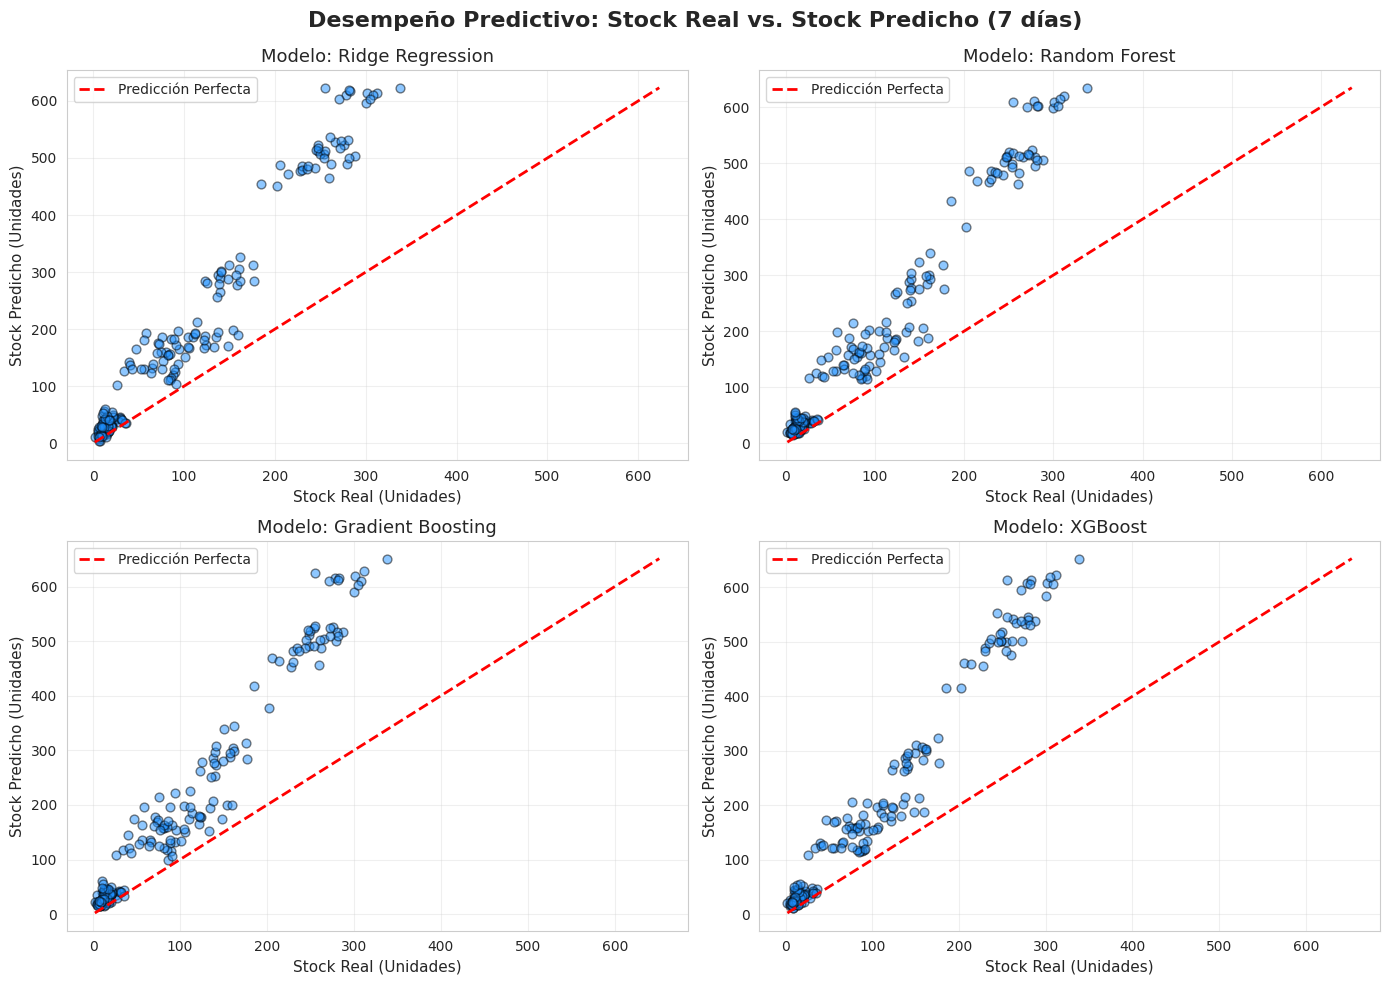

In [118]:
import matplotlib.pyplot as plt

# Crear una figura espaciosa para 4 gráficos (2 filas x 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Desempeño Predictivo: Stock Real vs. Stock Predicho (7 días)', fontsize=16, fontweight='bold')

# Aplanar la matriz de gráficos para que sea fácil iterar sobre ella
axes = axes.flatten()

print("--- Generando gráficos de Regresión ---")

for idx, (name, model) in enumerate(models.items()):
    # 1. El modelo ya está entrenado del paso anterior, solo predecimos
    y_pred = model.predict(X_test_7d)

    # 2. Seleccionar el subgráfico que toca
    ax = axes[idx]

    # 3. Graficar los puntos (Real vs Predicción)
    ax.scatter(y_test_7d, y_pred, alpha=0.5, color='dodgerblue', edgecolor='k', s=40)

    # 4. Dibujar la línea de "Predicción Perfecta" (diagonal)
    min_val = min(y_test_7d.min(), y_pred.min())
    max_val = max(y_test_7d.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta')

    # 5. Estética del gráfico
    ax.set_title(f'Modelo: {name}', fontsize=13)
    ax.set_xlabel('Stock Real (Unidades)', fontsize=11)
    ax.set_ylabel('Stock Predicho (Unidades)', fontsize=11)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

# Ajustar los espacios para que no se superpongan los títulos
plt.tight_layout()
plt.subplots_adjust(top=0.92)

# Mostrar la obra de arte
plt.show()

--- Generando gráficos de Regresión (14 días) ---


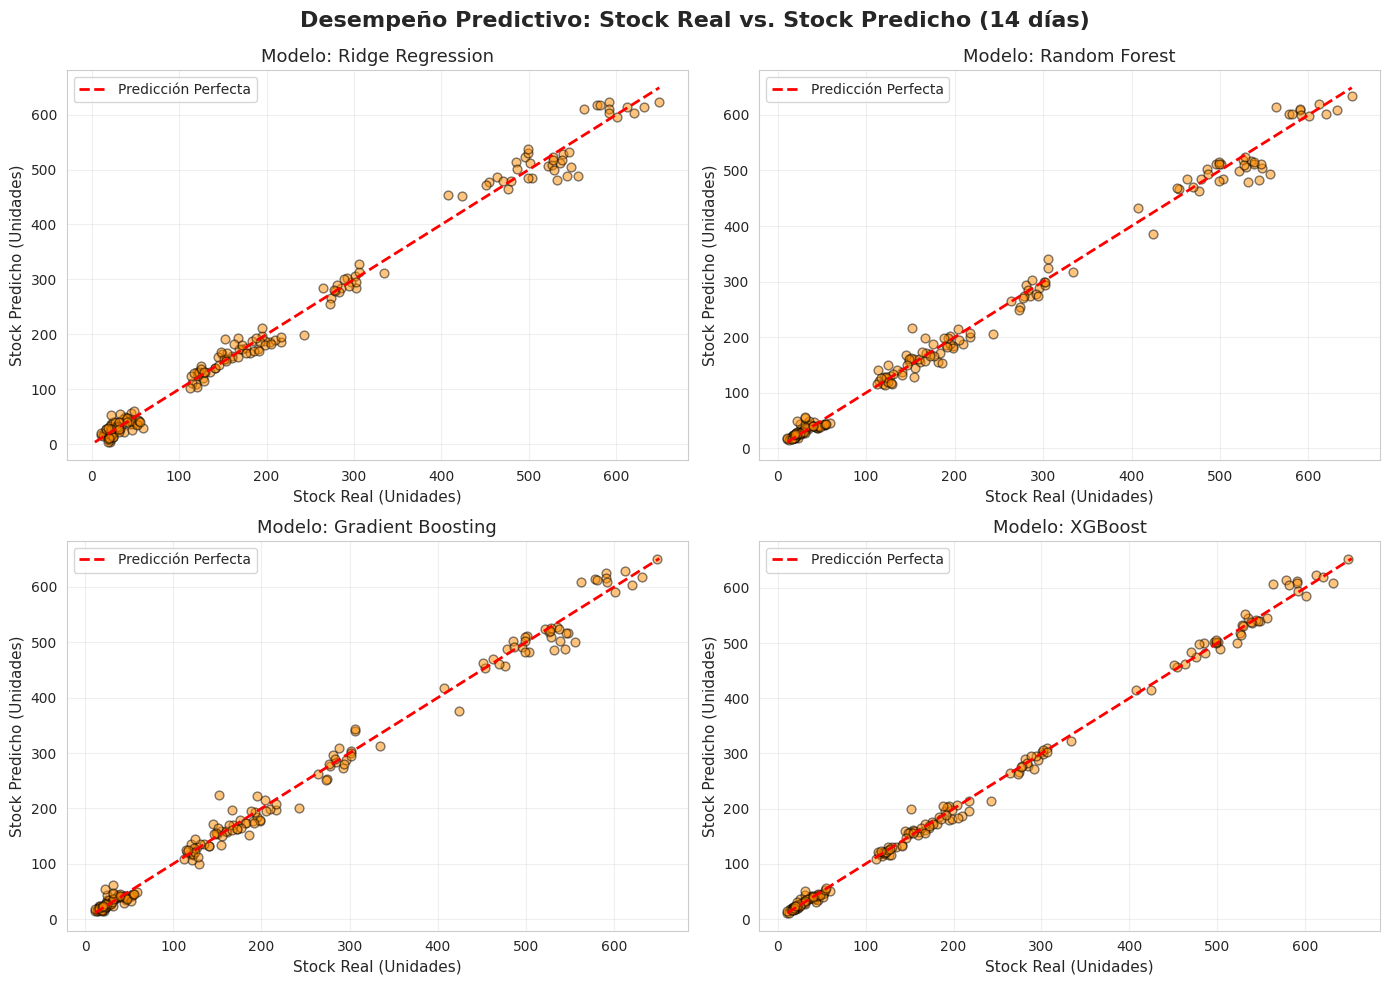

In [119]:
import matplotlib.pyplot as plt

# Crear una figura espaciosa para 4 gráficos (2 filas x 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Desempeño Predictivo: Stock Real vs. Stock Predicho (14 días)', fontsize=16, fontweight='bold')

# Aplanar la matriz de gráficos para que sea fácil iterar sobre ella
axes = axes.flatten()

print("--- Generando gráficos de Regresión (14 días) ---")

for idx, (name, model) in enumerate(models.items()):
    # 1. Predecir usando los datos de prueba de 14 días
    y_pred = model.predict(X_test_14d)

    # 2. Seleccionar el subgráfico que toca
    ax = axes[idx]

    # 3. Graficar los puntos (Real vs Predicción)
    ax.scatter(y_test_14d, y_pred, alpha=0.5, color='darkorange', edgecolor='k', s=40)

    # 4. Dibujar la línea de "Predicción Perfecta" (diagonal)
    min_val = min(y_test_14d.min(), y_pred.min())
    max_val = max(y_test_14d.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta')

    # 5. Estética del gráfico
    ax.set_title(f'Modelo: {name}', fontsize=13)
    ax.set_xlabel('Stock Real (Unidades)', fontsize=11)
    ax.set_ylabel('Stock Predicho (Unidades)', fontsize=11)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

# Ajustar los espacios para que no se superpongan los títulos
plt.tight_layout()
plt.subplots_adjust(top=0.92)

# Mostrar el gráfico
plt.show()

### 6. Curvas de Aprendizaje de los Modelos

Las curvas de aprendizaje nos ayudan a diagnosticar si un modelo tiene un problema de sesgo (underfitting) o varianza (overfitting). Muestran cómo el rendimiento del modelo en los conjuntos de entrenamiento y validación cambia con la cantidad de datos de entrenamiento.

In [120]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None,
                        cv=None, n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    """
    Generate 3 plots: the test and training learning curve, the training
    samples vs. fit times curve, and the fit times vs. score curve.

    Parameters
    ----------
    estimator : estimator instance
        A object of that type that is cloned for each validation for each fold.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features),
        Target vector as relationship to X.

    axes : array-like of shape (3,), optional
        Axes to plot the curves on.

    ylim : tuple, shape (ymin, ymax), optional
        Defines limits for the y-axis.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 5-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional
        Number of jobs to run in parallel.
        ``-1`` means using all processors.
        Defaults to None which means 1 unless in a :func:`joblib.parallel_backend` context.

    train_sizes : array-like, shape (n_ticks,),
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve.

    """
    if axes is None:
        _, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].set_title(title)
    if ylim is not None:
        axes[0].set_ylim(*ylim)
    axes[0].set_xlabel("Tamaño del conjunto de entrenamiento")
    axes[0].set_ylabel("Score")

    train_sizes, train_scores, test_scores, fit_times, _ = \
        learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs,
                       train_sizes=train_sizes, return_times=True)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    fit_times_mean = np.mean(fit_times, axis=1)
    fit_times_std = np.std(fit_times, axis=1)

    # Plot learning curve
    axes[0].grid()
    axes[0].fill_between(train_sizes, train_scores_mean - train_scores_std,
                         train_scores_mean + train_scores_std, alpha=0.1,
                         color="r")
    axes[0].fill_between(train_sizes, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1,
                         color="g")
    axes[0].plot(train_sizes, train_scores_mean, 'o-', color="r",
                 label="Training score")
    axes[0].plot(train_sizes, test_scores_mean, 'o-', color="g",
                 label="Cross-validation score")
    axes[0].legend(loc="best")

    # Plot n_samples vs fit_times
    axes[1].grid()
    axes[1].plot(train_sizes, fit_times_mean, 'o-')
    axes[1].fill_between(train_sizes, fit_times_mean - fit_times_std,
                         fit_times_mean + fit_times_std, alpha=0.1)
    axes[1].set_xlabel("Tamaño del conjunto de entrenamiento")
    axes[1].set_ylabel("Tiempo de ajuste (segundos)")
    axes[1].set_title("Escalabilidad del modelo")

    # Plot fit_times vs score
    axes[2].grid()
    axes[2].plot(fit_times_mean, test_scores_mean, 'o-')
    axes[2].fill_between(fit_times_mean, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1)
    axes[2].set_xlabel("Tiempo de ajuste (segundos)")
    axes[2].set_ylabel("Score")
    axes[2].set_title("Rendimiento del modelo")

    return plt


### Curvas de Aprendizaje para `stock_critico_7d`

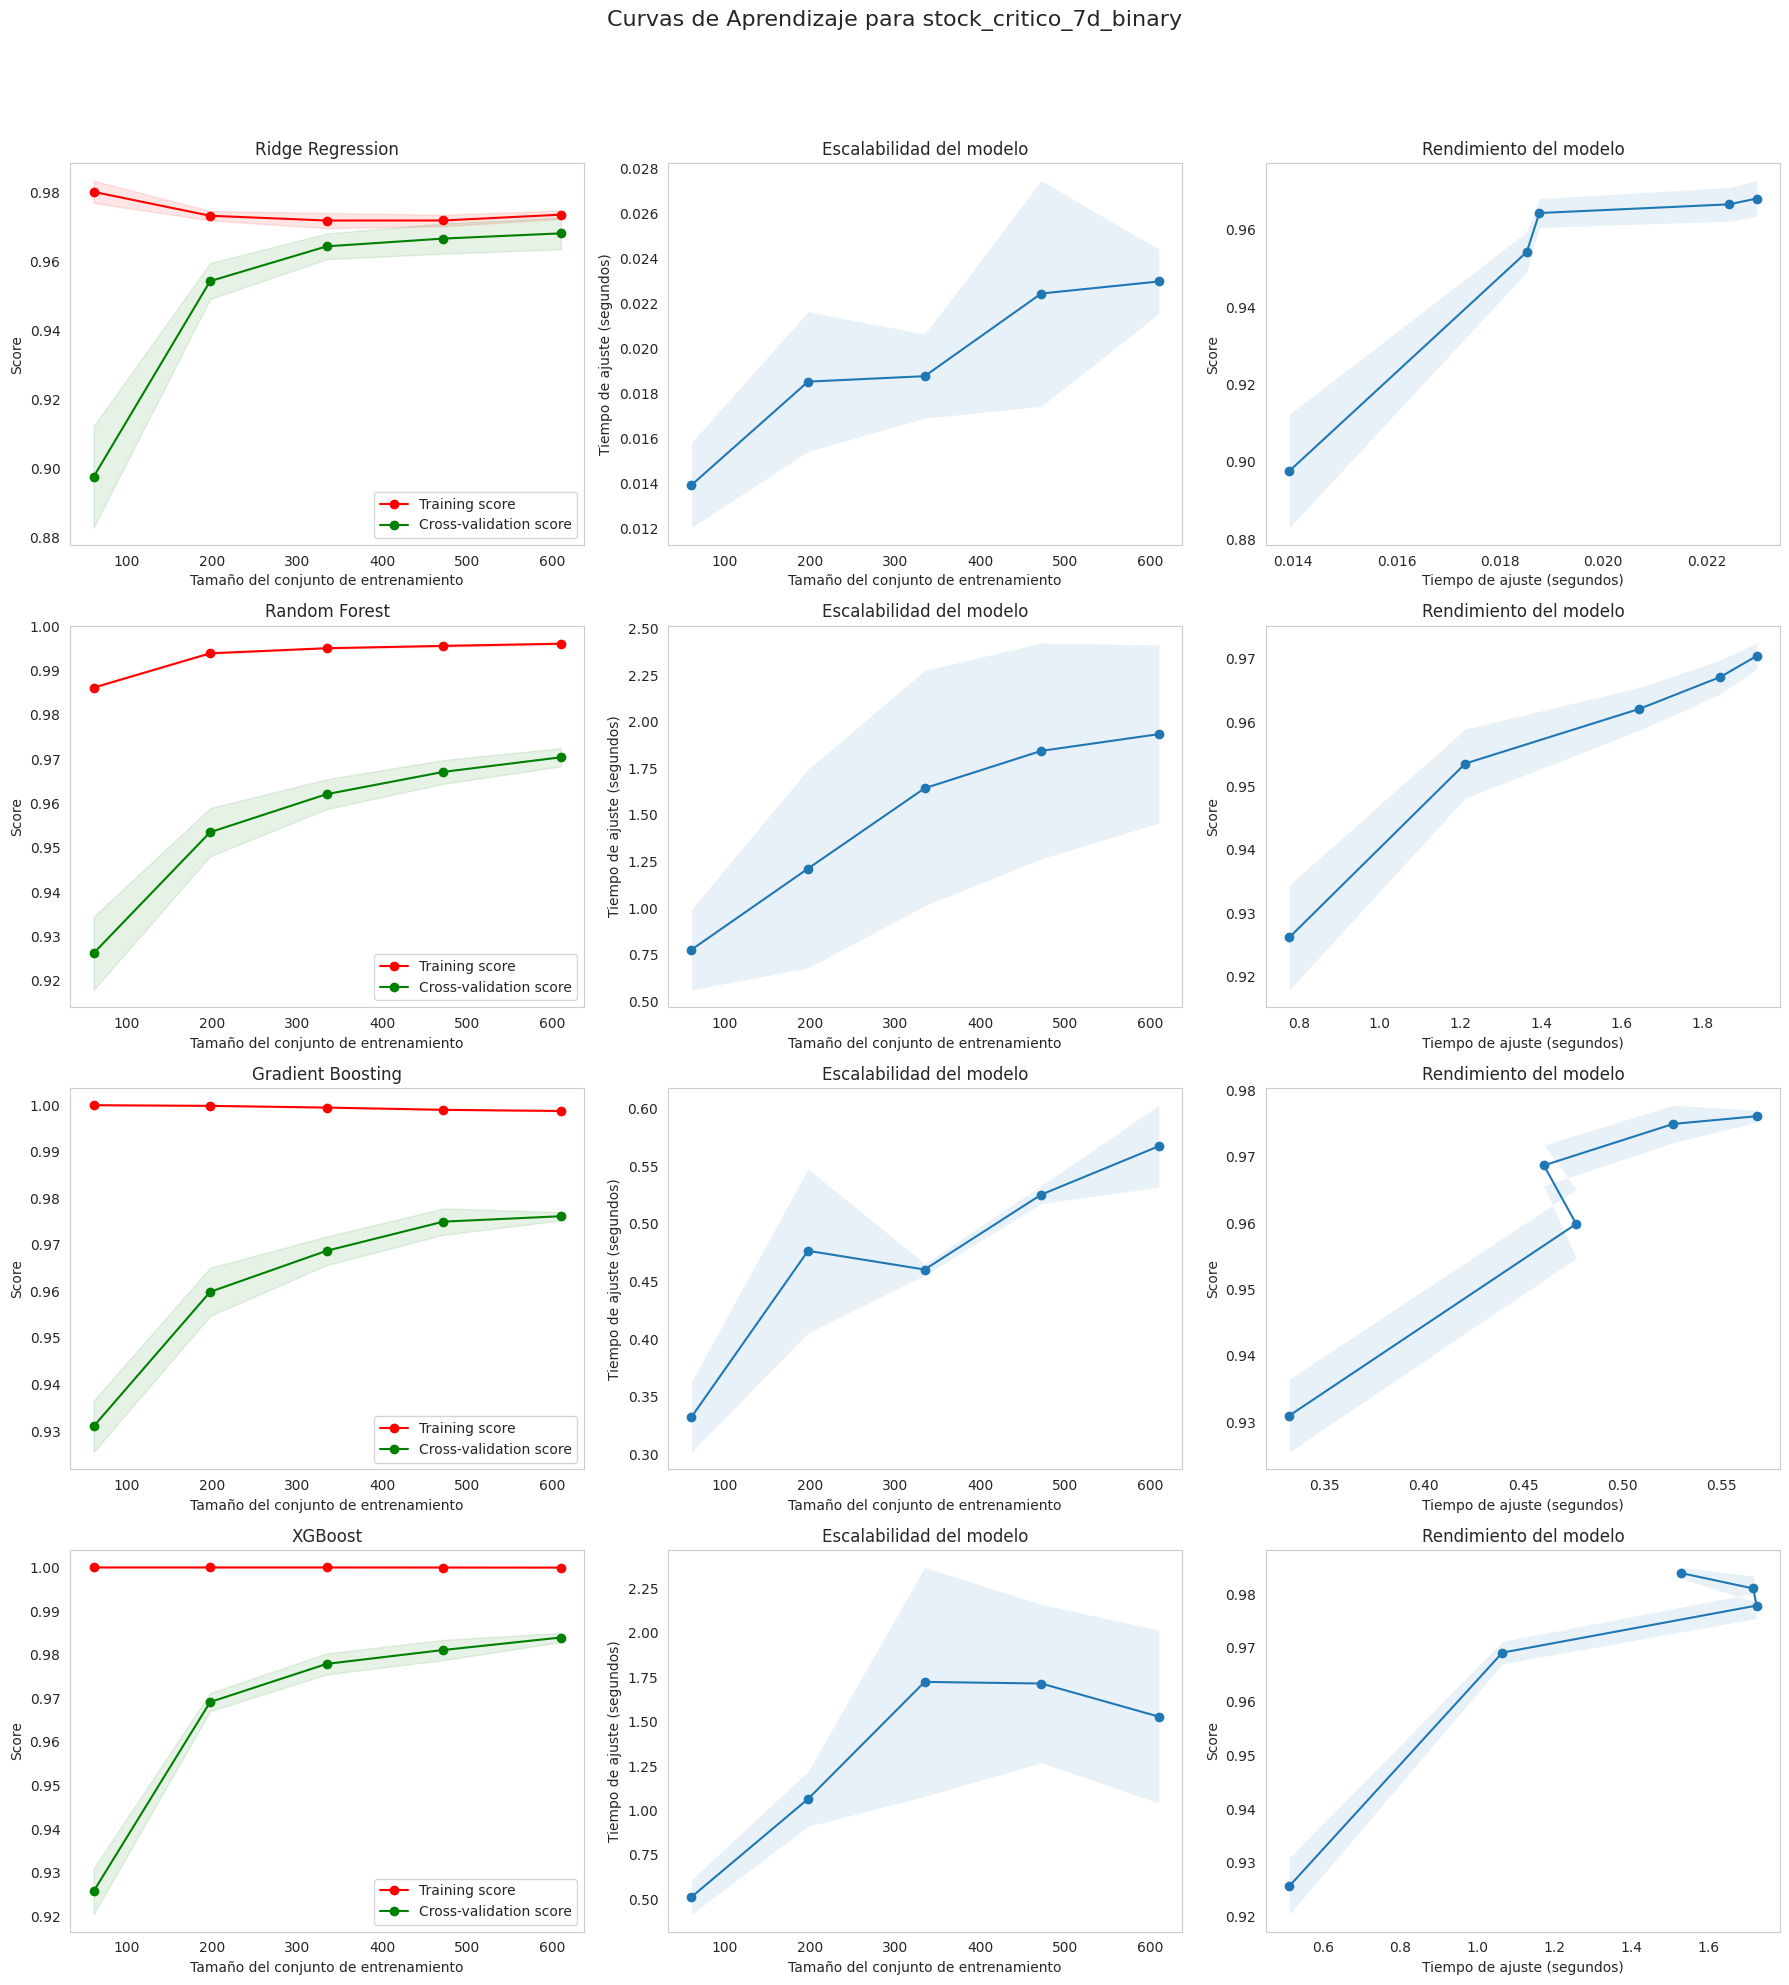

In [121]:
X_combined_7d = pd.concat([X_train_7d, X_test_7d], axis=0)
y_combined_7d = pd.concat([y_train_7d, y_test_7d], axis=0)

fig, axes = plt.subplots(len(models), 3, figsize=(18, 5 * len(models)))
fig.suptitle('Curvas de Aprendizaje para stock_critico_7d_binary', fontsize=16, y=1.02)

for i, (name, estimator) in enumerate(models.items()):
    plot_learning_curve(estimator, name, X_combined_7d, y_combined_7d, axes=axes[i] if len(models) > 1 else axes, cv=3, n_jobs=-1)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Curvas de Aprendizaje para `stock_critico_14d`

In [123]:
print("Columnas de características (X) utilizadas para el entrenamiento:")
display(pd.Series(X.columns))

Columnas de características (X) utilizadas para el entrenamiento:


,0
0,semana
1,mes
2,anio
3,ocupacion_deseada
4,ocupacion_albergue
...,...
82,tipo_stock_terapia_dirigida
83,unidad_medida_kits
84,unidad_medida_sobres
85,unidad_medida_tabletas


### 7. Interpretación de Parámetros del Modelo: Pesos y Sesgos / Importancia de Características

Aquí podemos examinar cómo cada modelo utiliza las características de entrada para hacer sus predicciones.

In [124]:
print("\n--- Interpretación de los modelos para stock_critico_7d ---")
for name, model in models.items():
    print(f"\nModelo: {name}")
    if hasattr(model, 'coef_') and hasattr(model, 'intercept_'):
        print("  Coeficientes (Pesos):")
        # Asociar coeficientes con nombres de características
        coefs = pd.Series(model.coef_[0], index=X_train_7d.columns)
        display(coefs.sort_values(ascending=False).head(10)) # Mostrar top 10 positivos
        display(coefs.sort_values(ascending=True).head(10))  # Mostrar top 10 negativos
        print(f"  Intercepción (Sesgo): {model.intercept_[0]:.4f}")
    elif hasattr(model, 'feature_importances_'):
        print("  Importancia de las Características:")
        importances = pd.Series(model.feature_importances_, index=X_train_7d.columns)
        display(importances.sort_values(ascending=False).head(10)) # Mostrar top 10

print("\n--- Interpretación de los modelos para stock_critico_14d ---")
for name, model in models.items():
    print(f"\nModelo: {name}")
    if hasattr(model, 'coef_') and hasattr(model, 'intercept_'):
        print("  Coeficientes (Pesos):")
        # Asociar coeficientes con nombres de características
        coefs = pd.Series(model.coef_[0], index=X_train_14d.columns)
        display(coefs.sort_values(ascending=False).head(10)) # Mostrar top 10 positivos
        display(coefs.sort_values(ascending=True).head(10))  # Mostrar top 10 negativos
        print(f"  Intercepción (Sesgo): {model.intercept_[0]:.4f}")
    elif hasattr(model, 'feature_importances_'):
        print("  Importancia de las Características:")
        importances = pd.Series(model.feature_importances_, index=X_train_14d.columns)
        display(importances.sort_values(ascending=False).head(10)) # Mostrar top 10



--- Interpretación de los modelos para stock_critico_7d ---

Modelo: Ridge Regression

Modelo: Random Forest
  Importancia de las Características:


,0
consumo_promedio_14d,0.140313
consumo_promedio_7d,0.133678
salidas_stock,0.090993
stock_minimo,0.084367
neto_movimiento,0.080664
consumo_lag_7,0.073095
consumo_lag_1,0.070860
unidad_medida_viales,0.044694
consumo_diario,0.043489
stock_cierre,0.032235



Modelo: Gradient Boosting
  Importancia de las Características:


,0
consumo_promedio_14d,0.106704
salidas_stock,0.097708
consumo_lag_1,0.094309
consumo_promedio_7d,0.093791
consumo_lag_7,0.088531
consumo_diario,0.059121
stock_minimo,0.058768
stock_actual,0.054032
unidad_medida_viales,0.049114
tipo_stock_soporte_nutricional,0.038758



Modelo: XGBoost
  Importancia de las Características:


...

,0
consumo_promedio_14d,0.140313
consumo_promedio_7d,0.133678
salidas_stock,0.090993
stock_minimo,0.084367
neto_movimiento,0.080664
consumo_lag_7,0.073095
consumo_lag_1,0.070860
unidad_medida_viales,0.044694
consumo_diario,0.043489
stock_cierre,0.032235



Modelo: Gradient Boosting
  Importancia de las Características:


,0
consumo_promedio_14d,0.106704
salidas_stock,0.097708
consumo_lag_1,0.094309
consumo_promedio_7d,0.093791
consumo_lag_7,0.088531
consumo_diario,0.059121
stock_minimo,0.058768
stock_actual,0.054032
unidad_medida_viales,0.049114
tipo_stock_soporte_nutricional,0.038758



Modelo: XGBoost
  Importancia de las Características:


,0
consumo_promedio_14d,0.379665
tipo_stock_soporte,0.158390
tipo_stock_soporte_nutricional,0.156003
consumo_promedio_7d,0.107372
categoria_item_nutricional,0.061146
stock_minimo,0.045398
item_id_ITEM014,0.034821
categoria_item_fluoropirimidina_oral,0.011449
item_id_ITEM002,0.010813
unidad_medida_viales,0.007019


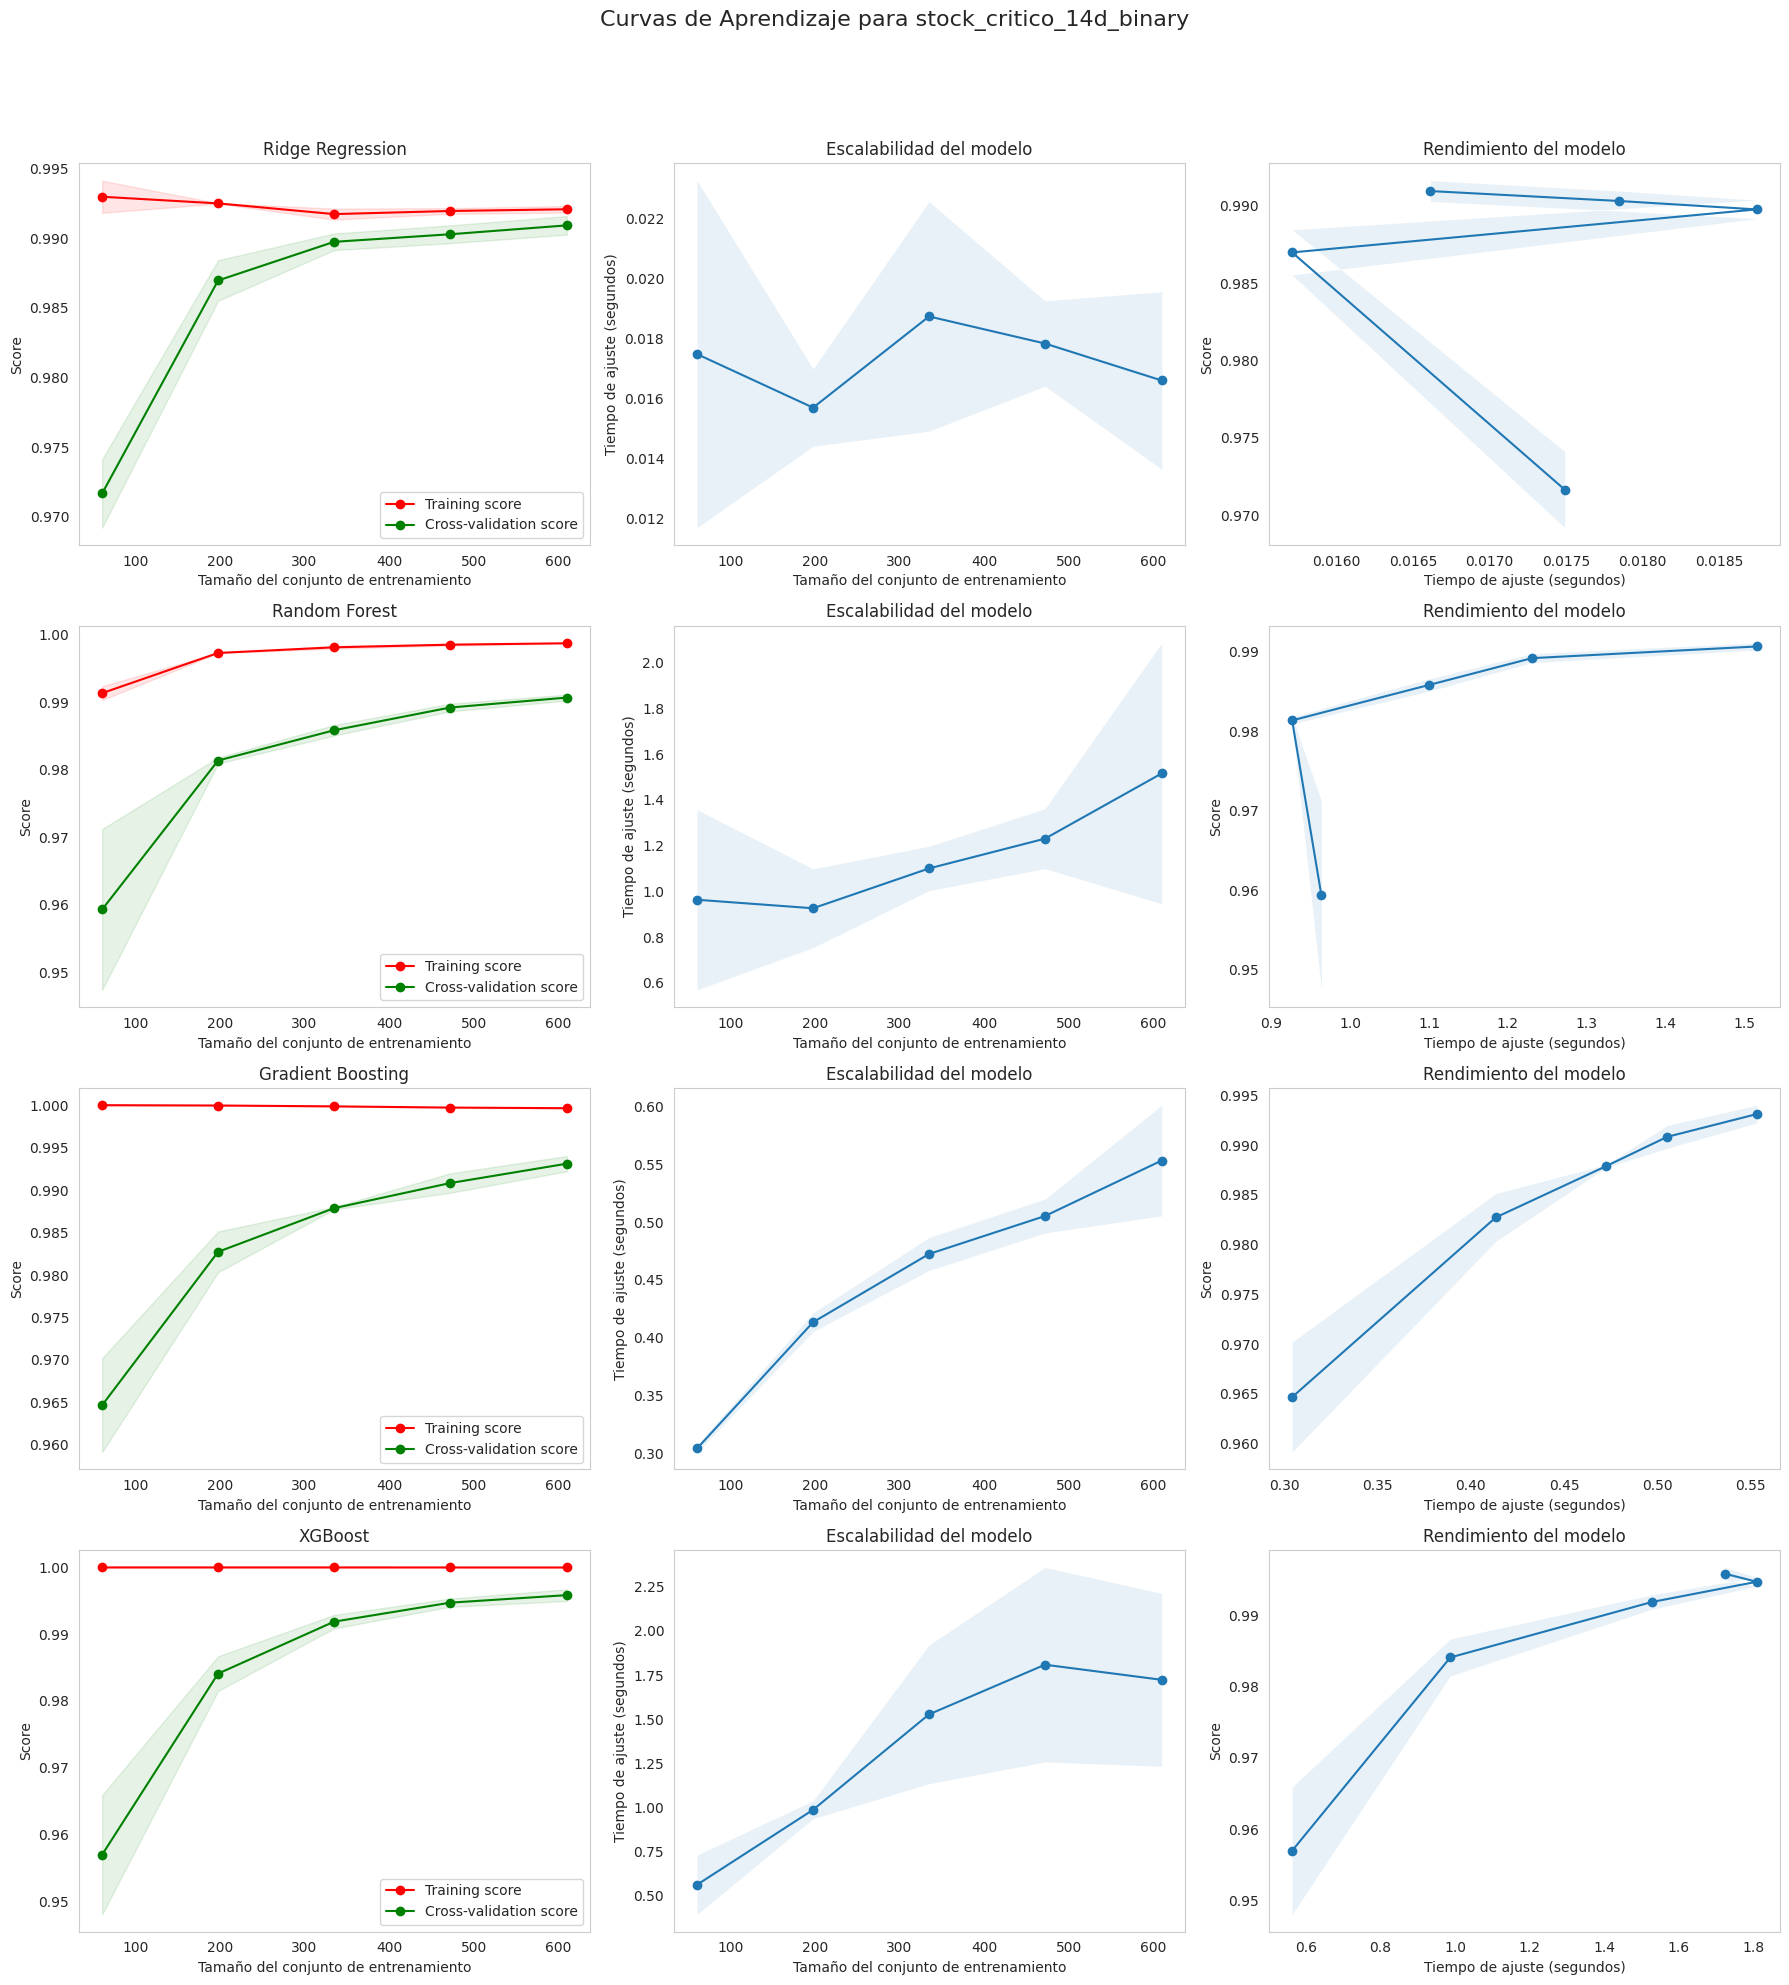

In [125]:
X_combined_14d = pd.concat([X_train_14d, X_test_14d], axis=0)
y_combined_14d = pd.concat([y_train_14d, y_test_14d], axis=0)

fig, axes = plt.subplots(len(models), 3, figsize=(18, 5 * len(models)))
fig.suptitle('Curvas de Aprendizaje para stock_critico_14d_binary', fontsize=16, y=1.02)

for i, (name, estimator) in enumerate(models.items()):
    plot_learning_curve(estimator, name, X_combined_14d, y_combined_14d, axes=axes[i] if len(models) > 1 else axes, cv=3, n_jobs=-1)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()